In [1]:
import json
import os
import pandas as pd
import seaborn as sns
sns.set(rc={'figure.figsize':(6,3)})
sns.set_style("white")
import matplotlib.pyplot as plt

In [2]:
feature_cols = ['color_fulness', 'tone', 'saturation', 'si', 'cpbd', 'blur_stength']

df = pd.read_json("features/all_images.json")
df = df[feature_cols + ["image"]]
df["image"] = df["image"].apply(lambda x: os.path.splitext(os.path.basename(x))[0])
df["filter"] = df["image"].apply(lambda x: x.split("_")[0])
df["base_img"] = df["image"].apply(lambda x: "_".join(x.split("_")[1:]))
df

,color_fulness,tone,saturation,si,cpbd,blur_stength,image,filter,base_img
0,129.585499,0.772146,6.462684,0.302379,0.950000,0.280301,aden_01_IMG_9832,aden,01_IMG_9832
1,128.518301,0.729382,8.425599,0.171659,0.902439,0.401430,aden_02_IMG_0047,aden,02_IMG_0047
2,93.140938,0.291226,39.503488,0.087453,0.382353,0.504624,aden_blume,aden,blume
3,143.604277,0.212196,27.529046,0.100812,0.885106,0.351465,aden_IMG_1665,aden,IMG_1665
4,151.089997,0.000000,11.462328,0.442580,0.873630,0.304453,aden_IMG_3867_4,aden,IMG_3867_4
...,...,...,...,...,...,...,...,...,...
1084,144.608349,0.005631,10.690845,0.448463,0.995169,0.219203,xproii_p50,xproii,p50
1085,119.171623,0.116617,34.680505,0.143945,0.784969,0.337351,xproii_p51,xproii,p51
1086,37.450166,0.955679,42.287751,0.142529,0.763578,0.404422,xproii_p52,xproii,p52
1087,93.699545,0.894356,16.399200,0.186567,0.892802,0.418955,xproii_p53,xproii,p53


In [3]:
dr = pd.read_csv("all_in_one.csv")
dr["stimuli_file"] = dr["stimuli_file"].apply(lambda x: os.path.splitext(os.path.basename(x))[0])
dr["base_img"] = dr["base_img"].apply(lambda x: os.path.splitext(x)[0])
dr

,stimuli_file,rating,filter,base_img,rating_type
0,aden_01_IMG_9832,4.200000,aden,01_IMG_9832,realism
1,aden_02_IMG_0047,4.125000,aden,02_IMG_0047,realism
2,aden_IMG_1665,4.200000,aden,IMG_1665,realism
3,aden_IMG_3867_4,3.500000,aden,IMG_3867_4,realism
4,aden_IMG_3995,3.200000,aden,IMG_3995,realism
...,...,...,...,...,...
3262,xproii_p50,3.250000,xproii,p50,appeal
3263,xproii_p51,4.166667,xproii,p51,appeal
3264,xproii_p52,3.142857,xproii,p52,appeal
3265,xproii_p53,4.000000,xproii,p53,appeal


In [4]:
drr = dr.pivot(index=["base_img", "stimuli_file", "filter"], columns="rating_type", values='rating').reset_index()
drr

rating_type,base_img,stimuli_file,filter,appeal,quality,realism
0,01_IMG_9832,aden_01_IMG_9832,aden,3.800000,3.900000,4.200000
1,01_IMG_9832,clarendon_01_IMG_9832,clarendon,4.000000,3.727273,3.909091
2,01_IMG_9832,gingham_01_IMG_9832,gingham,4.100000,3.900000,4.300000
3,01_IMG_9832,hudson_01_IMG_9832,hudson,4.285714,4.428571,3.857143
4,01_IMG_9832,lark_01_IMG_9832,lark,3.875000,4.000000,4.250000
...,...,...,...,...,...,...
1084,p54,normal_p54,org,4.428571,4.142857,3.857143
1085,p54,perpetua_p54,perpetua,3.857143,3.571429,3.714286
1086,p54,rise_p54,rise,4.363636,4.545455,4.454545
1087,p54,valencia_p54,valencia,4.800000,4.800000,3.600000


In [5]:
dm = pd.merge(drr, df, left_on=["stimuli_file"], right_on=["image"])
dm

,base_img_x,stimuli_file,filter_x,appeal,quality,realism,color_fulness,tone,saturation,si,cpbd,blur_stength,image,filter_y,base_img_y
0,01_IMG_9832,aden_01_IMG_9832,aden,3.800000,3.900000,4.200000,129.585499,0.772146,6.462684,0.302379,0.950000,0.280301,aden_01_IMG_9832,aden,01_IMG_9832
1,01_IMG_9832,clarendon_01_IMG_9832,clarendon,4.000000,3.727273,3.909091,131.950564,0.895039,24.942424,0.383959,0.933962,0.277842,clarendon_01_IMG_9832,clarendon,01_IMG_9832
2,01_IMG_9832,gingham_01_IMG_9832,gingham,4.100000,3.900000,4.300000,162.348219,0.625835,8.990287,0.274028,0.965909,0.279865,gingham_01_IMG_9832,gingham,01_IMG_9832
3,01_IMG_9832,hudson_01_IMG_9832,hudson,4.285714,4.428571,3.857143,163.216786,0.677858,19.267209,0.270577,0.948052,0.285800,hudson_01_IMG_9832,hudson,01_IMG_9832
4,01_IMG_9832,lark_01_IMG_9832,lark,3.875000,4.000000,4.250000,159.700071,0.691744,15.566391,0.326662,0.941176,0.276668,lark_01_IMG_9832,lark,01_IMG_9832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1084,p54,normal_p54,org,4.428571,4.142857,3.857143,159.991329,0.414279,34.398057,0.252902,0.920000,0.336802,normal_p54,normal,p54
1085,p54,perpetua_p54,perpetua,3.857143,3.571429,3.714286,157.935196,0.442119,47.973600,0.249740,0.927393,0.337782,perpetua_p54,perpetua,p54
1086,p54,rise_p54,rise,4.363636,4.545455,4.454545,160.384154,0.448187,20.719045,0.252785,0.927500,0.336849,rise_p54,rise,p54
1087,p54,valencia_p54,valencia,4.800000,4.800000,3.600000,92.511906,0.452895,34.883294,0.276879,0.909804,0.336830,valencia_p54,valencia,p54


In [6]:

def calc_corrs(dm, cols):
    
    res = []
    for fc in cols:
        t = {"metric": fc}
        for x in [ "appeal", "quality", "realism"]:
            t = dict({
                        f"{x}_p": dm[[fc, x]].corr(method="pearson")[fc].values[1],
                        f"{x}_k": dm[[fc, x]].corr(method="kendall")[fc].values[1],
                        f"{x}_s": dm[[fc, x]].corr(method="spearman")[fc].values[1],
                    }, 
                     **t
            )
        res.append(t)
    return res
    
dres = pd.DataFrame(calc_corrs(dm, feature_cols)).sort_values(by=["appeal_p"])
dres

,realism_p,realism_k,realism_s,quality_p,quality_k,quality_s,appeal_p,appeal_k,appeal_s,metric
3,0.002301,0.023887,0.034248,-0.010678,0.001151,0.000609,-0.062281,-0.029013,-0.043105,si
5,-0.123930,-0.092797,-0.136592,0.008174,-0.009607,-0.014477,-0.054117,-0.062551,-0.093922,blur_stength
0,0.099557,0.061583,0.089578,0.045021,0.041880,0.062664,0.015590,0.016759,0.026058,color_fulness
2,0.035691,0.045745,0.065988,0.056754,0.052710,0.077295,0.038133,0.048952,0.073091,saturation
1,0.129876,0.070052,0.102879,0.113500,0.078706,0.116138,0.071035,0.037296,0.054880,tone
4,0.124226,0.080649,0.118630,0.145084,0.119889,0.179141,0.134394,0.114904,0.169243,cpbd


<Axes: ylabel='metric'>

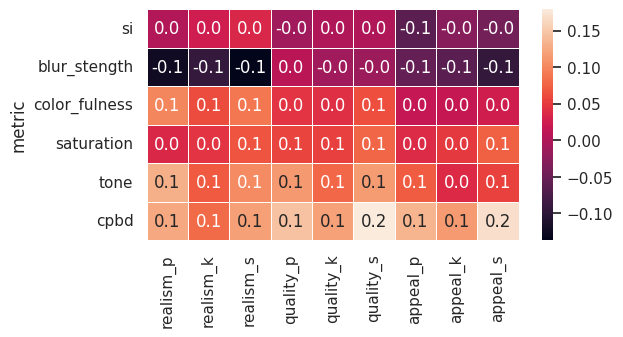

In [7]:
sns.heatmap(dres.set_index("metric"), annot = True, fmt = '.1f', linewidths=.5)

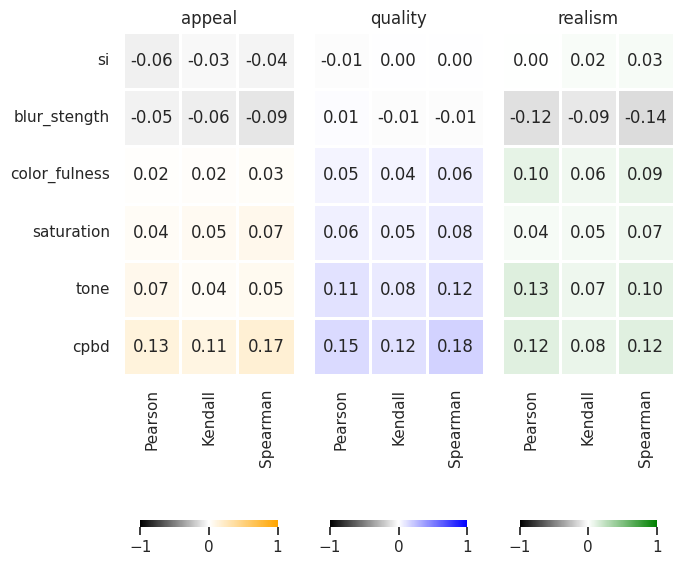

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

fig, axes = plt.subplots(1, 3, figsize=(7, 10))

rating_types = ['appeal', 'quality', 'realism']
rating_display_colors = {'realism': 'green', 'quality': 'blue', 'appeal': 'orange'}  # Base colors for palettes
opposite_colors = {
    'realism': 'purple',      # opposite of green on color wheel
    'quality': 'orange',       # opposite of blue
    'appeal': 'blue'          # opposite of orange
}

for idx, rating in enumerate(rating_types):
    # Create dark palette for this rating
    # reverse=False means darker = higher values
    colors_list = ["black", 'white', rating_display_colors[rating]]
    
    # Create the colormap
    cmap = LinearSegmentedColormap.from_list(f'{rating}_diverging', colors_list, N=256)
    # Alternative: if you want white->color instead of dark->color
    # cmap = sns.light_palette(base_colors[rating], as_cmap=True, reverse=False)
    
    # Select columns for this rating type
    rating_cols = [col for col in dres.columns if col.startswith(rating) and col != 'metric']
    df_rating = dres.set_index('metric')[rating_cols]
    
    # Rename columns to just filter type
    df_rating.columns = [col.split('_')[1] for col in df_rating.columns]
    df_rating = df_rating.rename(columns={"p": "Pearson", "k": "Kendall", "s": "Spearman"})
    # Create heatmap
    heatmap = sns.heatmap(df_rating, annot=True, fmt='.2f', 
                cmap=cmap,
                vmin=-1.0, vmax=1.0,
                linewidths=1, 
                linecolor='white',
                #cbar=idx==2,  # Only show colorbar on last plot
                ax=axes[idx],square=True,
                cbar_kws={
                    'label': '',
                    'shrink': 0.8,
                    'ticks': [-1.0, 0, 1.0],  # Fixed ticks
                    'pad': 0.15,
                    'orientation': 'horizontal',
                },
               )
    
    # Customize
    if idx > 0:
        axes[idx].tick_params(axis='y', labelleft=False)
    axes[idx].set_title(f'{rating}')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')


plt.tight_layout()
plt.savefig("features_corr.pdf", bbox_inches='tight')
plt.show()

In [9]:
diqa = pd.read_json("iqa/res.json").reset_index()
diqa = diqa.rename(columns={"index": "image"})
diqa = diqa[diqa["image"] != "mean"]
diqa["image"] = diqa["image"].apply(lambda x: os.path.splitext(os.path.basename(x))[0])
iqa_cols = list(diqa.columns.difference(["image"]))
print(iqa_cols)
print(len(iqa_cols))
diqa

['arniqa', 'brisque', 'clipiqa+', 'hyperiqa', 'ilniqe', 'laion_aes', 'liqe', 'maniqa', 'musiq', 'nima-koniq', 'niqe', 'piqe', 'qalign', 'qualiclip+', 'topiq_iaa', 'tres', 'unique', 'wadiqam_nr']
18


,image,arniqa,brisque,clipiqa+,hyperiqa,ilniqe,laion_aes,liqe,maniqa,musiq,nima-koniq,niqe,piqe,qalign,qualiclip+,topiq_iaa,tres,unique,wadiqam_nr
0,aden_01_IMG_9832,0.637782,5.211853,0.618298,0.600675,32.279279,5.067049,3.491646,0.456217,67.372719,0.639139,3.762905,44.424786,4.437500,0.569635,5.536321,75.883331,0.625614,0.015914
1,aden_02_IMG_0047,0.660168,11.919861,0.576679,0.587229,27.337404,5.365654,3.041514,0.416481,67.245964,0.591684,4.001696,27.051466,4.191406,0.566699,5.291119,71.410851,0.861928,-0.124231
2,aden_IMG_1665,0.533681,59.225037,0.400626,0.338316,37.157622,4.877734,1.715546,0.344957,42.126366,0.542330,5.887926,58.403313,3.123047,0.461016,5.467540,38.881123,0.073502,-0.351516
3,aden_IMG_3867_4,0.628389,26.393372,0.551406,0.393309,25.323561,5.591468,1.580214,0.193632,51.602425,0.637862,3.055200,32.207928,3.818359,0.462635,5.740246,59.822479,0.392078,-0.146271
4,aden_IMG_3995,0.599448,-5.761780,0.426024,0.394481,25.965870,5.538328,1.247512,0.262465,56.006981,0.628337,3.254416,27.688488,3.134766,0.429299,5.412809,48.755634,0.220992,-0.467780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1084,xproii_p50,0.701242,71.470276,0.619288,0.629806,29.860548,6.134042,3.612699,0.417507,58.162468,0.573220,18.411795,43.430771,4.011719,0.562056,5.872757,82.098877,1.181468,-0.100656
1085,xproii_p51,0.548195,23.345642,0.520147,0.470738,22.980638,6.102436,1.798933,0.240886,56.889652,0.531163,2.877741,39.184872,3.863281,0.536644,5.909233,50.419140,0.258337,-0.740564
1086,xproii_p52,0.605747,47.978455,0.518193,0.530208,27.509553,5.599547,2.586458,0.354078,59.189362,0.504606,4.318998,49.357464,3.994141,0.530373,5.624175,65.305382,0.700560,-0.561750
1087,xproii_p53,0.699901,24.547791,0.602645,0.557020,22.944177,6.219031,3.714922,0.356417,71.147736,0.662144,3.611703,40.105106,4.332031,0.562228,5.283161,61.618256,1.390008,-0.391502


In [10]:
dmi = pd.merge(drr, diqa, left_on=["stimuli_file"], right_on=["image"])
dmi

,base_img,stimuli_file,filter,appeal,quality,realism,image,arniqa,brisque,clipiqa+,...,musiq,nima-koniq,niqe,piqe,qalign,qualiclip+,topiq_iaa,tres,unique,wadiqam_nr
0,01_IMG_9832,aden_01_IMG_9832,aden,3.800000,3.900000,4.200000,aden_01_IMG_9832,0.637782,5.211853,0.618298,...,67.372719,0.639139,3.762905,44.424786,4.437500,0.569635,5.536321,75.883331,0.625614,0.015914
1,01_IMG_9832,clarendon_01_IMG_9832,clarendon,4.000000,3.727273,3.909091,clarendon_01_IMG_9832,0.654653,6.061951,0.629945,...,72.258156,0.652894,3.635092,46.608498,4.468750,0.596178,5.566700,77.088120,1.472001,0.002746
2,01_IMG_9832,gingham_01_IMG_9832,gingham,4.100000,3.900000,4.300000,gingham_01_IMG_9832,0.699319,4.913513,0.654467,...,72.088341,0.653161,3.752483,40.511345,4.550781,0.584327,5.381069,81.370888,0.852159,-0.155427
3,01_IMG_9832,hudson_01_IMG_9832,hudson,4.285714,4.428571,3.857143,hudson_01_IMG_9832,0.647474,2.897400,0.620167,...,68.631630,0.626256,3.785272,42.135159,4.156250,0.571576,5.464810,76.216331,0.871286,0.007592
4,01_IMG_9832,lark_01_IMG_9832,lark,3.875000,4.000000,4.250000,lark_01_IMG_9832,0.645640,8.002502,0.633422,...,70.009529,0.634598,3.814534,46.173172,4.394531,0.578202,5.450131,77.243301,0.905756,-0.012340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1084,p54,normal_p54,org,4.428571,4.142857,3.857143,normal_p54,0.675353,9.596375,0.669596,...,62.635933,0.688854,3.011863,26.455355,4.136719,0.588111,5.281957,54.469536,0.895552,-0.295953
1085,p54,perpetua_p54,perpetua,3.857143,3.571429,3.714286,perpetua_p54,0.681944,9.361755,0.668688,...,65.503052,0.678928,3.098094,24.504953,4.171875,0.577865,5.346623,55.378006,0.864447,-0.302590
1086,p54,rise_p54,rise,4.363636,4.545455,4.454545,rise_p54,0.656180,8.372498,0.646442,...,62.811245,0.674360,2.960059,26.385906,4.125000,0.572166,5.428343,53.674549,0.779942,-0.265646
1087,p54,valencia_p54,valencia,4.800000,4.800000,3.600000,valencia_p54,0.642477,8.123230,0.659997,...,62.653976,0.654854,2.982900,26.918736,3.982422,0.571099,5.174091,43.225731,0.601736,-0.475351


In [11]:
dres_iqa = pd.DataFrame(calc_corrs(dmi, iqa_cols)).sort_values(by=["appeal_p"])
dres_iqa

,realism_p,realism_k,realism_s,quality_p,quality_k,quality_s,appeal_p,appeal_k,appeal_s,metric
11,-0.027313,0.007287,0.009424,-0.165100,-0.104880,-0.153271,-0.241666,-0.140486,-0.206509,piqe
1,-0.111581,-0.051078,-0.077491,-0.155211,-0.120487,-0.176093,-0.171785,-0.114790,-0.168435,brisque
10,-0.134690,-0.099467,-0.146693,-0.140256,-0.115610,-0.171373,-0.165927,-0.126496,-0.186321,niqe
4,-0.134917,-0.076516,-0.113208,-0.059237,-0.034445,-0.049571,-0.097509,-0.042691,-0.061535,ilniqe
15,0.239372,0.160423,0.233772,0.185644,0.129927,0.192872,0.098191,0.065279,0.097635,tres
17,0.159523,0.099672,0.148228,0.224449,0.153806,0.230856,0.108142,0.068565,0.101149,wadiqam_nr
3,0.234934,0.157251,0.228275,0.292358,0.205053,0.300747,0.168079,0.110148,0.162550,hyperiqa
7,0.242491,0.174563,0.255115,0.294066,0.211957,0.310711,0.182002,0.121075,0.180797,maniqa
0,0.240188,0.139200,0.205758,0.323579,0.214387,0.314776,0.190318,0.100477,0.146884,arniqa
8,0.204471,0.143076,0.207116,0.361714,0.274063,0.398256,0.194444,0.135772,0.201225,musiq


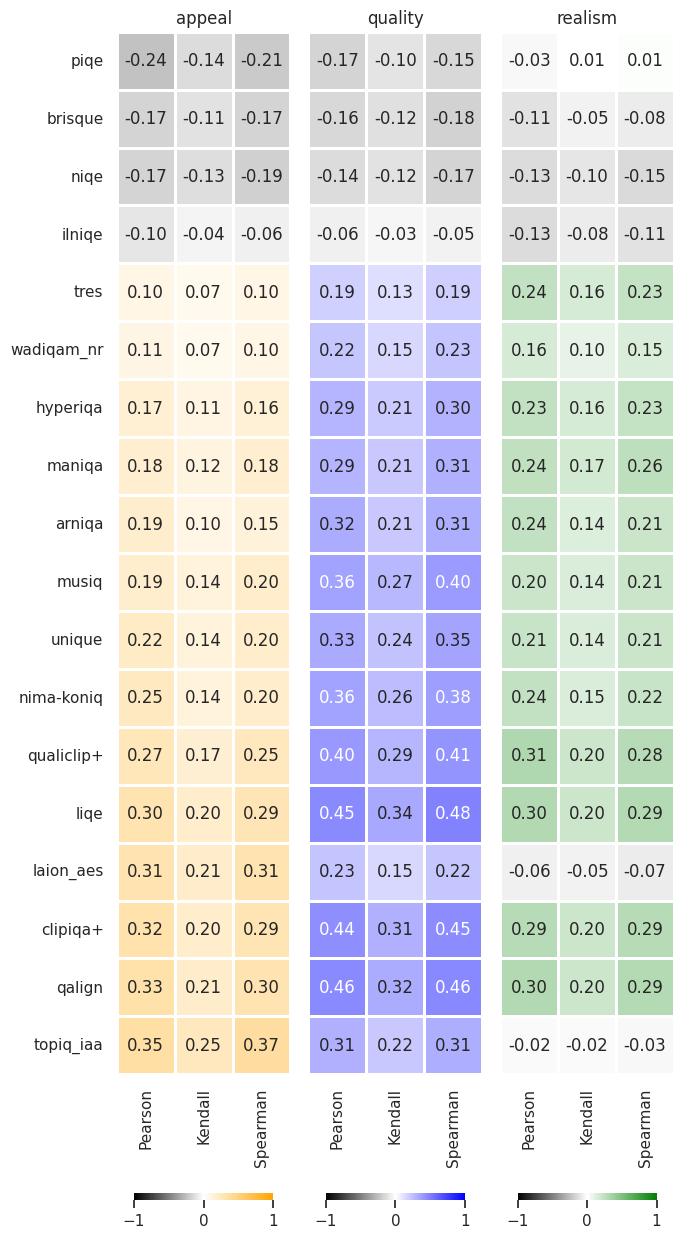

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

fig, axes = plt.subplots(1, 3, figsize=(7, 30))  # 10 ^= 6

rating_types = ['appeal', 'quality', 'realism']
rating_display_colors = {'realism': 'green', 'quality': 'blue', 'appeal': 'orange'}  # Base colors for palettes
opposite_colors = {
    'realism': 'purple',      # opposite of green on color wheel
    'quality': 'orange',       # opposite of blue
    'appeal': 'blue'          # opposite of orange
}

for idx, rating in enumerate(rating_types):
    # Create dark palette for this rating
    # reverse=False means darker = higher values
    colors_list = ["black", 'white', rating_display_colors[rating]]
    
    # Create the colormap
    cmap = LinearSegmentedColormap.from_list(f'{rating}_diverging', colors_list, N=256)
    # Alternative: if you want white->color instead of dark->color
    # cmap = sns.light_palette(base_colors[rating], as_cmap=True, reverse=False)
    
    # Select columns for this rating type
    rating_cols = [col for col in dres_iqa.columns if col.startswith(rating) and col != 'metric']
    df_rating = dres_iqa.set_index('metric')[rating_cols]
    
    # Rename columns to just filter type
    df_rating.columns = [col.split('_')[1] for col in df_rating.columns]
    df_rating = df_rating.rename(columns={"p": "Pearson", "k": "Kendall", "s": "Spearman"})
    # Create heatmap
    heatmap = sns.heatmap(df_rating, annot=True, fmt='.2f', 
                cmap=cmap,
                vmin=-1.0, vmax=1.0,
                linewidths=1, 
                linecolor='white',
                #cbar=idx==2,  # Only show colorbar on last plot
                ax=axes[idx],square=True,
                cbar_kws={
                    'label': '',
                    'shrink': 0.8,
                    'ticks': [-1.0, 0, 1.0],  # Fixed ticks
                    'pad': 0.04,
                    'orientation': 'horizontal',
                },
               )
    
    # Customize
    if idx > 0:
        axes[idx].tick_params(axis='y', labelleft=False)
    axes[idx].set_title(f'{rating}')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')


plt.tight_layout()
plt.savefig("iqa_corr.pdf", bbox_inches='tight')
plt.show()